In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("house_prices.csv")
# print(df)
# print(df.columns)
# print(df.info)
# print(df.isnull().sum())
# print(df.describe())

#what relationship do you expect between Area and Price?
#What relationship do you expect between Distance and price?
#What relationship do you expect between Age and Price?

correlation = df.corr(numeric_only=True)

print(correlation["Price_lakh"].sort_values(ascending=False))


# plt.scatter(df["Area_sqft"], df["Price_lakh"])
# plt.xlabel("Area")
# plt.ylabel("Price")
# plt.tight_layout()
# plt.show()

# plt.scatter(df["Age_years"], df["Price_lakh"])
# plt.xlabel("Age years")
# plt.ylabel("Price")
# plt.tight_layout()
# plt.show()


#train and test
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data= pd.DataFrame(df)
X= data[["Age_years","Area_sqft","Bathrooms","Bedrooms","Distance_km"]]
Y= data["Price_lakh"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


model=LinearRegression()

model.fit(X_train, y_train)

predictions= model.predict(X_test)

print("Actual:", y_test.values) 
print("Predicted:", predictions)




#prediction
new_house= pd.DataFrame({
    "Age_years": [5],
    "Area_sqft": [1000],
    "Bathrooms": [2],
    "Bedrooms": [2],
    "Distance_km": [10]
})
print("Age:", new_house["Age_years"].iloc[0])
print("Area:", new_house["Area_sqft"].iloc[0])
print("Bathrooms:", new_house["Bathrooms"].iloc[0])
print("Bedrooms:", new_house["Bedrooms"].iloc[0])



#efficiency
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")
    
results = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": predictions.round(1),
    }
)

print(results.head())

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions,
) ** 0.5

r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")  #mean absolute error
print(f"RMSE: {rmse:.2f}") #mean squared error
print(f"R2 Score: {r2:.2f}") # r2 score


Price_lakh     1.000000
Area_sqft      0.781081
Bathrooms      0.388401
Bedrooms       0.137391
Distance_km   -0.297591
Age_years     -0.408462
Name: Price_lakh, dtype: float64
Actual: [162.8 381.4 391.8 507.4 398.6 343.7 298.2 349.6 341.3 108.  202.2 388.2]
Predicted: [157.12306888 384.63478014 400.68796244 503.50609496 360.89127716
 357.38104008 276.99986408 341.25947711 300.42112255 122.08730139
 216.97241629 345.5781932 ]
Age: 5
Area: 1000
Bathrooms: 2
Bedrooms: 2
Intercept: 62.72736529043749
Age_years: -4.04
Area_sqft: 0.11
Bathrooms: 26.45
Bedrooms: 18.99
Distance_km: -4.17
    Actual  Predicted
0    162.8      157.1
5    381.4      384.6
36   391.8      400.7
45   507.4      503.5
13   398.6      360.9
MAE: 17.92
RMSE: 22.67
R2 Score: 0.96


First five rows:
   Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_km  Price_lakh
0        996         5          2         29         12.1       162.8
1       2503         4          3          4         13.3       427.8
2       2240         3          2         15          2.6       365.6
3       1765         5          2         21          8.9       318.8
4       1753         3          3         15          1.8       334.0

Dataset shape:
(60, 6)

Missing values:
Area_sqft      0
Bedrooms       0
Bathrooms      0
Age_years      0
Distance_km    0
Price_lakh     0
dtype: int64

Statistical summary:
         Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_km  Price_lakh
count    60.000000  60.00000  60.000000  60.000000    60.000000   60.000000
mean   1955.683333   3.55000   2.000000  15.050000    10.166667  305.581667
std     607.380636   1.14129   0.781133   8.187268     5.630988   90.959960
min     896.000000   2.00000   1.000000   0.000000     1.400000  108.000000
25%  

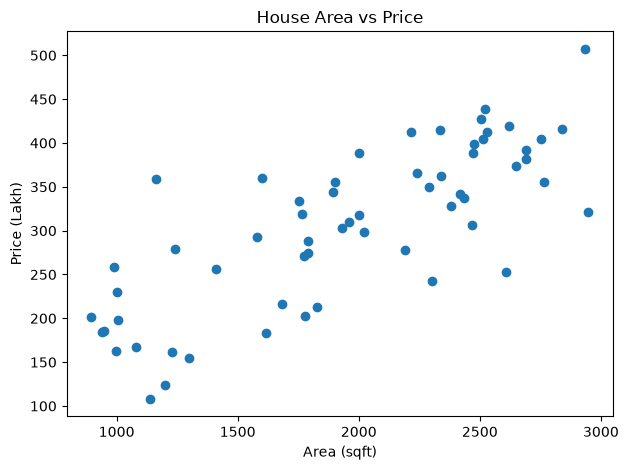

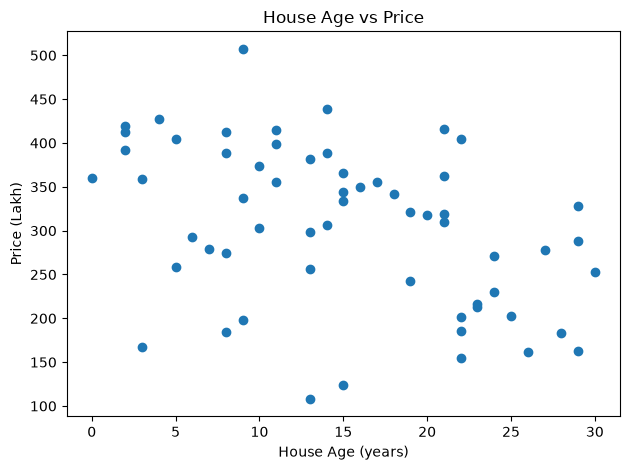


Correlation with Price:
Price_lakh     1.000000
Area_sqft      0.781081
Bathrooms      0.388401
Bedrooms       0.137391
Distance_km   -0.297591
Age_years     -0.408462
Name: Price_lakh, dtype: float64

Model Evaluation
----------------
MAE: 17.92
RMSE: 22.67
R2 Score: 0.96

Actual vs Predicted:
    Actual  Predicted
0    162.8      157.1
5    381.4      384.6
36   391.8      400.7
45   507.4      503.5
13   398.6      360.9

New House Prediction
--------------------
Estimated price: 325.55 lakh


In [40]:
#sir's code

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split


def load_data(file_name):
    """Load the house price dataset."""
    return pd.read_csv(file_name)


def explore_data(data):
    """Display basic information about the dataset."""
    print("First five rows:")
    print(data.head())

    print("\nDataset shape:")
    print(data.shape)

    print("\nMissing values:")
    print(data.isnull().sum())

    print("\nStatistical summary:")
    print(data.describe())


def create_visualizations(data):
    """Create basic visualizations."""
    plt.scatter(
        data["Area_sqft"],
        data["Price_lakh"],
    )

    plt.xlabel("Area (sqft)")
    plt.ylabel("Price (Lakh)")
    plt.title("House Area vs Price")
    plt.tight_layout()
    plt.show()

    plt.scatter(
        data["Age_years"],
        data["Price_lakh"],
    )

    plt.xlabel("House Age (years)")
    plt.ylabel("Price (Lakh)")
    plt.title("House Age vs Price")
    plt.tight_layout()
    plt.show()


def train_model(data):
    """Train the house price prediction model."""
    features = [
        "Area_sqft",
        "Bedrooms",
        "Bathrooms",
        "Age_years",
        "Distance_km",
    ]

    X = data[features]
    y = data["Price_lakh"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    return model, X_test, y_test


def evaluate_model(model, X_test, y_test):
    """Evaluate the trained model."""
    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions,
    )

    rmse = mean_squared_error(
        y_test,
        predictions,
    ) ** 0.5

    r2 = r2_score(
        y_test,
        predictions,
    )

    print("\nModel Evaluation")
    print("----------------")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    results = pd.DataFrame(
        {
            "Actual": y_test,
            "Predicted": predictions.round(1),
        }
    )

    print("\nActual vs Predicted:")
    print(results.head())

    return predictions


def predict_new_house(model):
    """Predict the price of a new house."""
    new_house = pd.DataFrame(
        {
            "Area_sqft": [1800],
            "Bedrooms": [3],
            "Bathrooms": [2],
            "Age_years": [8],
            "Distance_km": [5],
        }
    )

    prediction = model.predict(new_house)

    print("\nNew House Prediction")
    print("--------------------")
    print(
        f"Estimated price: "
        f"{prediction[0]:.2f} lakh"
    )


def main():
    """Run the complete house price project."""
    data = load_data("house_prices.csv")

    explore_data(data)

    create_visualizations(data)

    correlation = data.corr(numeric_only=True)

    print("\nCorrelation with Price:")
    print(
        correlation["Price_lakh"]
        .sort_values(ascending=False)
    )

    model, X_test, y_test = train_model(data)

    evaluate_model(
        model,
        X_test,
        y_test,
    )

    predict_new_house(model)


if __name__ == "__main__":
    main()